<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/ravindu/DL_assignmnet_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile  # <-- add this line

# Extract the dataset (modify the path according to your file location)
dataset_path = '/content/drive/MyDrive/SE4050/DATASET.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")


✅ Dataset extracted successfully!


In [3]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [4]:
# Correct paths
dataset_path = "/content/dataset/DATASET"
train_path = os.path.join(dataset_path, "TRAIN")
test_path = os.path.join(dataset_path, "TEST")

# Check that paths exist
print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))

# Parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 20
FINE_TUNE_EPOCHS = 10


Train path exists: True
Test path exists: True


In [5]:
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    validation_split=0.2  # 80% train, 20% validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Data loaders
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [6]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # binary output
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    epochs=EPOCHS
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 283s 486ms/step - accuracy: 0.7698 - loss: 0.5417 - val_accuracy: 0.7861 - val_loss: 0.4449
Epoch 2/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 268s 475ms/step - accuracy: 0.8198 - loss: 0.4170 - val_accuracy: 0.7797 - val_loss: 0.4392
Epoch 3/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 326s 482ms/step - accuracy: 0.8302 - loss: 0.3990 - val_accuracy: 0.8067 - val_loss: 0.4113
Epoch 4/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 268s 475ms/step - accuracy: 0.8438 - loss: 0.3854 - val_accuracy: 0.8061 - val_loss: 0.4350
Epoch 5/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 273s 483ms/step - accuracy: 0.8474 - loss: 0.3747 - val_accuracy: 0.8081 - val_loss: 0.4054
Epoch 6/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 272s 482ms/step - accuracy: 0.8571 - loss: 0.3496 - val_accuracy: 0.8360 - val_loss: 0.3608
Epoch 7/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 268s 474ms/step - accuracy: 0.8515 - loss: 0.3560 - val_accuracy: 0.8353 - val_loss: 0.3703
Epoch 8/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 270s 478ms/step - accuracy: 0.8613 -

In [8]:
# Reduce learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    epochs=FINE_TUNE_EPOCHS
)


Epoch 1/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 278s 486ms/step - accuracy: 0.8817 - loss: 0.2870 - val_accuracy: 0.8739 - val_loss: 0.3083
Epoch 2/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 274s 484ms/step - accuracy: 0.8919 - loss: 0.2697 - val_accuracy: 0.8770 - val_loss: 0.3013
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 274s 484ms/step - accuracy: 0.8884 - loss: 0.2761 - val_accuracy: 0.8728 - val_loss: 0.3010
Epoch 4/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 327s 494ms/step - accuracy: 0.8901 - loss: 0.2679 - val_accuracy: 0.8757 - val_loss: 0.2993
Epoch 5/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 273s 484ms/step - accuracy: 0.8957 - loss: 0.2619 - val_accuracy: 0.8794 - val_loss: 0.2938
Epoch 6/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 272s 481ms/step - accuracy: 0.8948 - loss: 0.2641 - val_accuracy: 0.8801 - val_loss: 0.2934
Epoch 7/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 279s 494ms/step - accuracy: 0.8956 - loss: 0.2609 - val_accuracy: 0.8808 - val_loss: 0.2975
Epoch 8/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 278s 493ms/step - accuracy: 0.8995 -

In [9]:
model.save("/content/drive/MyDrive/garbage_classifier_cnn.h5")
print("✅ Model saved to Drive!")


✅ Model saved to Drive!


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step

Classification Report:
              precision    recall  f1-score   support

     Organic       0.88      0.95      0.92      1401
  Recyclable       0.93      0.84      0.88      1112

    accuracy                           0.90      2513
   macro avg       0.91      0.90      0.90      2513
weighted avg       0.90      0.90      0.90      2513



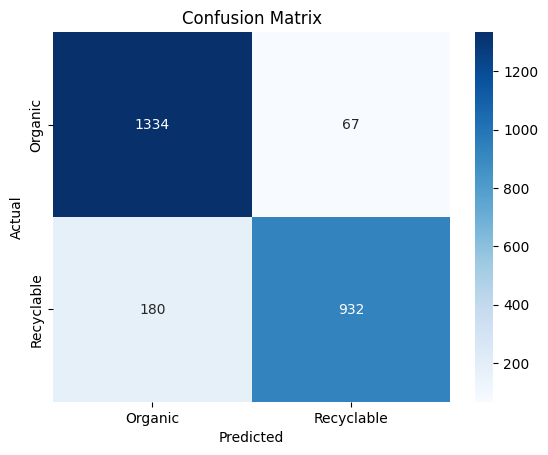

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype("int32").flatten()
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Organic', 'Recyclable']))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Organic', 'Recyclable'],
            yticklabels=['Organic', 'Recyclable'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

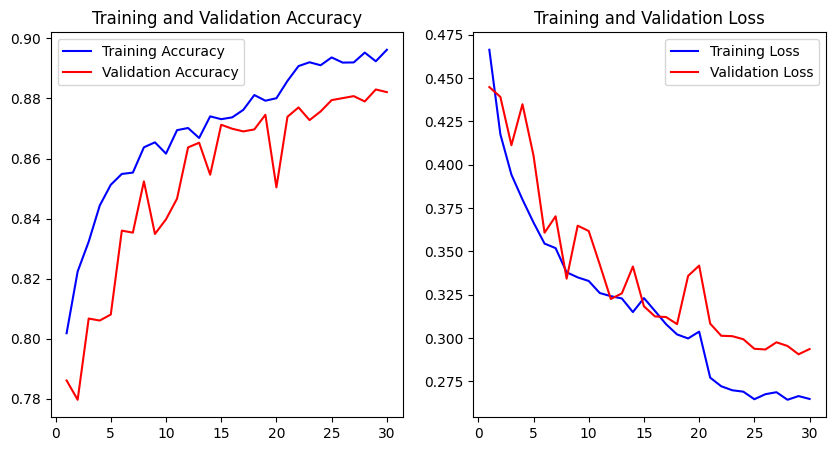

In [12]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']

loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [15]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"🧾 Test Accuracy: {test_acc*100:.2f}%")


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9429 - loss: 0.1672
🧾 Test Accuracy: 90.17%


In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image


In [17]:
print(train_generator.class_indices)


{'O': 0, 'R': 1}


In [18]:
# Path to your test image (can be from Drive or uploaded to Colab)
img_path = '/content/drive/MyDrive/SE4050/plastic_bottle.jpeg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # rescale like during training


In [19]:
prediction = model.predict(img_array)
print("Raw model output:", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
Raw model output: [[0.97259176]]


In [20]:
if prediction[0][0] > 0.5:
    print("♻️ Predicted: Recyclable")
else:
    print("🍂 Predicted: Organic")


♻️ Predicted: Recyclable


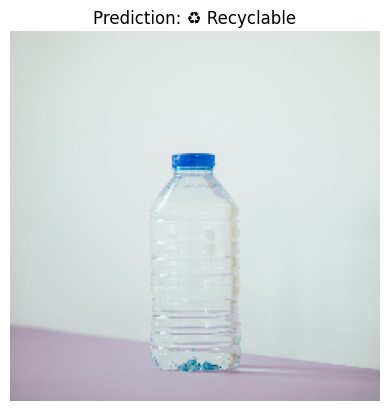

In [21]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')
label = "♻️ Recyclable" if prediction[0][0] > 0.5 else "🍂 Organic"
plt.title(f"Prediction: {label}")
plt.show()


In [22]:
# Path to your test image (can be from Drive or uploaded to Colab)
img_path = '/content/drive/MyDrive/SE4050/paper.jpg'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # rescale like during training

In [23]:
prediction = model.predict(img_array)
print("Raw model output:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw model output: [[0.9801911]]


In [24]:
if prediction[0][0] > 0.5:
    print("♻️ Predicted: Recyclable")
else:
    print("🍂 Predicted: Organic")


♻️ Predicted: Recyclable


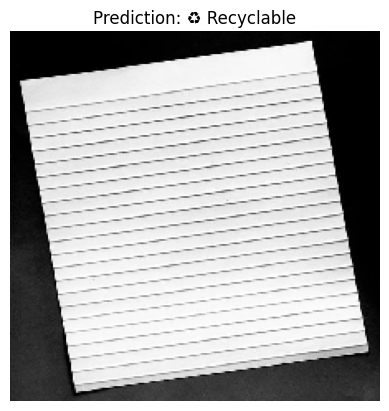

In [25]:

plt.imshow(img)
plt.axis('off')
label = "♻️ Recyclable" if prediction[0][0] > 0.5 else "🍂 Organic"
plt.title(f"Prediction: {label}")
plt.show()

In [26]:
# Path to your test image (can be from Drive or uploaded to Colab)
img_path = '/content/drive/MyDrive/SE4050/bread.webp'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # rescale like during training

In [27]:
prediction = model.predict(img_array)
print("Raw model output:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Raw model output: [[0.37186435]]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


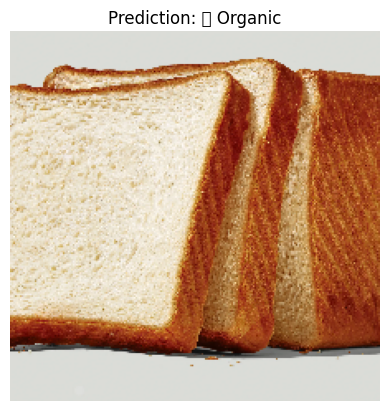

In [28]:

plt.imshow(img)
plt.axis('off')
label = "♻️ Recyclable" if prediction[0][0] > 0.5 else "🍂 Organic"
plt.title(f"Prediction: {label}")
plt.show()

In [30]:
# Path to your test image (can be from Drive or uploaded to Colab)
img_path = '/content/drive/MyDrive/SE4050/heuman.png'

# Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # rescale like during training

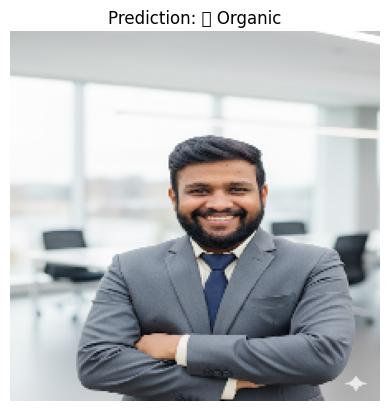

In [31]:

plt.imshow(img)
plt.axis('off')
label = "♻️ Recyclable" if prediction[0][0] > 0.5 else "🍂 Organic"
plt.title(f"Prediction: {label}")
plt.show()